# Notebook 12.1: Pre-entrenamiento GPT y Masked Self-Attention

Este notebook muestra cómo se entrena un modelo de lenguaje causal (GPT-like) desde cero,
con foco en dos ideas centrales:

- **Masked self-attention**: por qué y cómo se enmascara la atención en un decoder.
- **Loop de pre-entrenamiento**: teacher forcing, cross-entropy token a token, y generación autoregresiva.

**Entorno recomendado:** Google Colab (CPU es suficiente).

## Sección 1 — Instalaciones e imports

In [1]:
# !pip install tokenizers --quiet

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import math
from tokenizers import Tokenizer
from tokenizers.models import WordLevel
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.trainers import WordLevelTrainer

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo: {device}")

Dispositivo: cuda


## Sección 2 — Corpus y tokenizador WordLevel

Usamos un corpus pequeño en español y construimos un tokenizador de **palabras** con la
librería `tokenizers` de HuggingFace, usando el modelo `WordLevel`.

El tokenizador se *entrena* sobre el corpus: aprende el vocabulario y asigna un ID entero
a cada palabra. `encode` convierte texto → lista de IDs; `decode` hace el camino inverso.

In [2]:
CORPUS = """
el gato duerme en el sofá
el perro corre por el parque
la niña lee un libro en el jardín
el sol brilla sobre el río
la lluvia cae sobre el campo
el pájaro canta en el árbol
la luna ilumina el camino
el viento mueve las hojas
la flor crece en el jardín
el niño juega con el perro
el gato y el perro duermen juntos
la niña y el niño juegan en el parque
el sol ilumina el jardín y el río
la luna y las estrellas brillan en el cielo
el viento mueve las hojas del árbol
""".strip()

# Construir y entrenar el tokenizador
tokenizer = Tokenizer(WordLevel(unk_token="<UNK>"))
tokenizer.pre_tokenizer = Whitespace()
trainer = WordLevelTrainer(
    special_tokens=["<PAD>", "<UNK>", "<BOS>", "<EOS>"],
    min_frequency=1,
)
tokenizer.train_from_iterator(CORPUS.splitlines(), trainer=trainer)

vocab_size = tokenizer.get_vocab_size()
PAD_ID     = tokenizer.token_to_id("<PAD>")

def encode(text: str) -> list[int]:
    return tokenizer.encode(text).ids

def decode(ids: list[int]) -> str:
    return tokenizer.decode([i for i in ids if i != PAD_ID])

# Vocabulario completo
print(f"Vocabulario ({vocab_size} tokens):")
for token, idx in sorted(tokenizer.get_vocab().items(), key=lambda x: x[1]):
    print(f"  {idx:3d}: {token}")

# Prueba
sample = "el gato duerme"
print(f"\nencode('{sample}') = {encode(sample)}")
print(f"decode(...)         = '{decode(encode(sample))}'")

Vocabulario (49 tokens):
    0: <PAD>
    1: <UNK>
    2: <BOS>
    3: <EOS>
    4: el
    5: en
    6: la
    7: y
    8: jardín
    9: las
   10: perro
   11: gato
   12: hojas
   13: ilumina
   14: luna
   15: mueve
   16: niña
   17: niño
   18: parque
   19: río
   20: sobre
   21: sol
   22: viento
   23: árbol
   24: brilla
   25: brillan
   26: cae
   27: camino
   28: campo
   29: canta
   30: cielo
   31: con
   32: corre
   33: crece
   34: del
   35: duerme
   36: duermen
   37: estrellas
   38: flor
   39: juega
   40: juegan
   41: juntos
   42: lee
   43: libro
   44: lluvia
   45: por
   46: pájaro
   47: sofá
   48: un

encode('el gato duerme') = [4, 11, 35]
decode(...)         = 'el gato duerme'


## Sección 3 — Dataset de lenguaje causal (teacher forcing)

La tarea de pre-entrenamiento causal es: dado el prefijo `x[0..t]`, predecir `x[t+1]`.

Se implementa con **teacher forcing**: cada muestra es una ventana de `seq_len+1` tokens,
partida en `input = ventana[:-1]` y `target = ventana[1:]`.
Con un solo forward pass se calcula la pérdida para todos los pasos de tiempo del batch.

```
Secuencia:  el  gato  duerme  en   el   sofá
Input:      el  gato  duerme  en   el          ← posiciones 0..4
Target:     gato duerme  en   el   sofá        ← posiciones 1..5
```

In [3]:
class WordDataset(torch.utils.data.Dataset):
    def __init__(self, corpus: str, seq_len: int):
        all_tokens = []
        for line in corpus.splitlines():
            all_tokens.extend(encode(line))
        self.data    = torch.tensor(all_tokens, dtype=torch.long)
        self.seq_len = seq_len

    def __len__(self):
        return max(0, len(self.data) - self.seq_len)

    def __getitem__(self, idx):
        chunk = self.data[idx : idx + self.seq_len + 1]
        return chunk[:-1], chunk[1:]   # (input, target)

SEQ_LEN    = 10
BATCH_SIZE = 8

dataset = WordDataset(CORPUS, SEQ_LEN)
loader  = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

x_sample, y_sample = next(iter(loader))
print(f"Forma del batch  →  x: {x_sample.shape}, y: {y_sample.shape}")
print(f"x[0] = '{decode(x_sample[0].tolist())}'")
print(f"y[0] = '{decode(y_sample[0].tolist())}'")

Forma del batch  →  x: torch.Size([8, 10]), y: torch.Size([8, 10])
x[0] = 'cae sobre el campo el pájaro canta en el árbol'
y[0] = 'sobre el campo el pájaro canta en el árbol la'


## Sección 4 — La máscara causal

El mecanismo de atención permite a cada token "mirar" a todos los demás.
En un **decoder** (GPT) esto es un problema: el token en la posición `t` no debe
ver los tokens futuros `t+1, t+2, ...` durante el entrenamiento.

La solución es una **máscara triangular inferior**: ponemos `-∞` en todas las
posiciones del triángulo superior antes del softmax. Como `softmax(-∞) = 0`,
la atención a tokens futuros queda exactamente anulada.

```
Posición  →  0  1  2  3  4
        0: [✓  ✗  ✗  ✗  ✗]   token 0 solo se atiende a sí mismo
        1: [✓  ✓  ✗  ✗  ✗]   token 1 ve 0 y 1
        2: [✓  ✓  ✓  ✗  ✗]
        3: [✓  ✓  ✓  ✓  ✗]
        4: [✓  ✓  ✓  ✓  ✓]
```

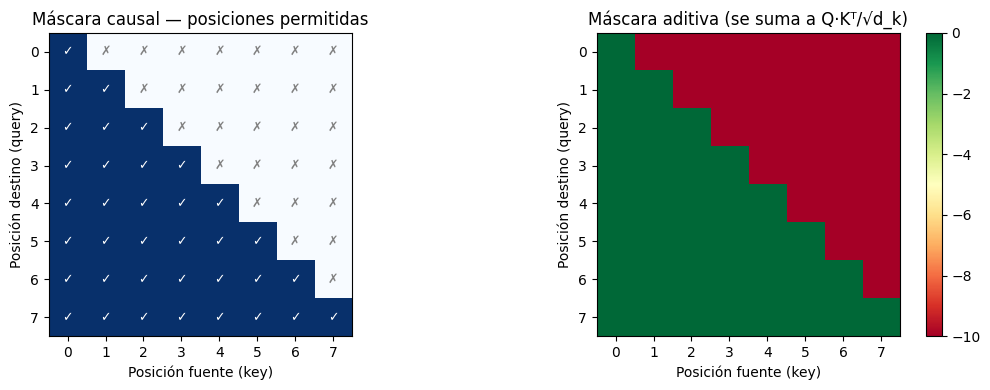

In [4]:
T    = 8
mask = torch.tril(torch.ones(T, T))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Panel izquierdo: máscara binaria
ax = axes[0]
ax.imshow(mask.numpy(), cmap="Blues", vmin=0, vmax=1)
ax.set_title("Máscara causal — posiciones permitidas", fontsize=12)
ax.set_xlabel("Posición fuente (key)"); ax.set_ylabel("Posición destino (query)")
for i in range(T):
    for j in range(T):
        ax.text(j, i, "✓" if mask[i,j] else "✗",
                ha='center', va='center',
                color='white' if mask[i,j] else 'gray', fontsize=9)
ax.set_xticks(range(T)); ax.set_yticks(range(T))

# Panel derecho: máscara aditiva (lo que se suma a los logits de atención)
additive = torch.zeros(T, T)
additive[mask == 0] = float('-inf')
vis = additive.numpy().copy(); vis[vis == float('-inf')] = -10
ax2 = axes[1]
im  = ax2.imshow(vis, cmap="RdYlGn", vmin=-10, vmax=0)
ax2.set_title("Máscara aditiva (se suma a Q·Kᵀ/√d_k)", fontsize=12)
ax2.set_xlabel("Posición fuente (key)"); ax2.set_ylabel("Posición destino (query)")
plt.colorbar(im, ax=ax2)
ax2.set_xticks(range(T)); ax2.set_yticks(range(T))

plt.tight_layout(); plt.show()

## Sección 5 — Causal Multi-Head Self-Attention

Implementación desde cero. Puntos clave:

- Las proyecciones Q, K, V se hacen con una sola matriz `(d_model → 3·d_model)` y luego se parten.
- El escalado por `√d_k` evita que los dot-products crezcan y saturen el softmax.
- La máscara se precomputa como `register_buffer`: no es un parámetro, pero se mueve al GPU con el modelo.
- `attn_w` (los pesos de atención) se devuelven para poder visualizarlos después.

In [6]:
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int, max_seq_len: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model  = d_model
        self.n_heads  = n_heads
        self.d_k      = d_model // n_heads

        self.qkv_proj = nn.Linear(d_model, 3 * d_model, bias=False)
        self.out_proj  = nn.Linear(d_model, d_model, bias=False)
        self.drop      = nn.Dropout(dropout)

        # Máscara aditiva: 0 donde permitido, -inf donde bloqueado
        am = torch.zeros(max_seq_len, max_seq_len)
        am[torch.tril(torch.ones(max_seq_len, max_seq_len)) == 0] = float('-inf')
        self.register_buffer("causal_mask", am.unsqueeze(0).unsqueeze(0))  # (1,1,T,T)

    def forward(self, x: torch.Tensor):
        B, T, C = x.shape

        # Proyectar y partir en Q, K, V
        q, k, v = self.qkv_proj(x).split(self.d_model, dim=-1)  # cada (B,T,d_model)

        # Reorganizar por cabezas: (B, n_heads, T, d_k)
        def rh(t): return t.view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        q, k, v = rh(q), rh(k), rh(v)

        # Scores escalados + máscara causal
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_k)  # (B,n_heads,T,T)
        scores = scores + self.causal_mask[:, :, :T, :T]           # -inf en futuro

        # Softmax → pesos de atención
        attn_w = self.drop(F.softmax(scores, dim=-1))              # triángulo sup. = 0

        # Suma ponderada de valores
        out = (attn_w @ v).transpose(1, 2).contiguous().view(B, T, C)
        return self.out_proj(out), attn_w

# Prueba de dimensiones
_x = torch.randn(2, SEQ_LEN, 64)
_attn = CausalSelfAttention(d_model=64, n_heads=4, max_seq_len=SEQ_LEN)
_out, _w = _attn(_x)
upper = _w[0, 0].detach().numpy()
mask_upper = np.triu(np.ones((SEQ_LEN, SEQ_LEN), dtype=bool), k=1)

max_val = upper[mask_upper].max()
print(f"Máximo valor en triángulo superior: {max_val:.6f}  (debe ser 0.0)")
print(f"Triángulo inferior + diagonal (pesos reales, suman 1 por fila):")
print(upper.round(3))

Máximo valor en triángulo superior: 0.000000  (debe ser 0.0)
Triángulo inferior + diagonal (pesos reales, suman 1 por fila):
[[0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.307 0.804 0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.32  0.493 0.299 0.    0.    0.    0.    0.    0.    0.   ]
 [0.201 0.399 0.254 0.    0.    0.    0.    0.    0.    0.   ]
 [0.259 0.    0.321 0.182 0.182 0.    0.    0.    0.    0.   ]
 [0.194 0.238 0.165 0.235 0.151 0.129 0.    0.    0.    0.   ]
 [0.12  0.15  0.    0.176 0.132 0.1   0.187 0.    0.    0.   ]
 [0.252 0.087 0.143 0.108 0.131 0.104 0.    0.132 0.    0.   ]
 [0.091 0.159 0.    0.166 0.103 0.102 0.13  0.    0.    0.   ]
 [0.111 0.062 0.099 0.077 0.123 0.189 0.104 0.081 0.119 0.146]]


## Sección 6 — Bloque Transformer (Pre-Norm GPT-style)

Cada bloque combina atención y una red feed-forward (MLP), con **Pre-Norm**:
la capa de normalización se aplica *antes* de cada sub-capa (no después, como en el
paper original). GPT-2 usa esta variante porque entrena de forma más estable.

```
x → LayerNorm → CausalSelfAttention → + residual
  → LayerNorm → MLP                 → + residual
```

In [7]:
class MLP(nn.Module):
    """Feed-forward de 2 capas con GELU y expansión ×4, igual que GPT-2."""
    def __init__(self, d_model: int, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model),
            nn.Dropout(dropout),
        )
    def forward(self, x): return self.net(x)


class TransformerBlock(nn.Module):
    def __init__(self, d_model: int, n_heads: int, max_seq_len: int, dropout: float = 0.1):
        super().__init__()
        self.ln1  = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, max_seq_len, dropout)
        self.ln2  = nn.LayerNorm(d_model)
        self.mlp  = MLP(d_model, dropout)

    def forward(self, x):
        a, w = self.attn(self.ln1(x))
        x    = x + a
        x    = x + self.mlp(self.ln2(x))
        return x, w

## Sección 7 — Modelo TinyGPT completo

```
Token IDs (B, T)
    ↓
Embedding de tokens  +  Embedding posicional (ambos aprendidos)
    ↓
N × TransformerBlock
    ↓
LayerNorm final
    ↓
Proyección lineal → logits (B, T, vocab_size)
```

**Weight tying:** `lm_head` comparte sus pesos con `tok_emb`. Reduce parámetros
y mejora generalización (Press & Wolf, 2017).

In [14]:
class TinyGPT(nn.Module):
    def __init__(
        self,
        vocab_size:  int,
        d_model:     int,
        n_heads:     int,
        n_layers:    int,
        max_seq_len: int,
        dropout:     float = 0.1,
    ):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_seq_len, d_model)
        self.drop    = nn.Dropout(dropout)
        self.blocks  = nn.ModuleList([
            TransformerBlock(d_model, n_heads, max_seq_len, dropout)
            for _ in range(n_layers)
        ])
        self.ln_f    = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.lm_head.weight = self.tok_emb.weight   # weight tying

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Embedding):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)

    def forward(self, idx: torch.Tensor):
        B, T = idx.shape
        pos  = torch.arange(T, device=idx.device)
        x    = self.drop(self.tok_emb(idx) + self.pos_emb(pos))
        attn_maps = []
        for blk in self.blocks:
            x, w = blk(x)
            attn_maps.append(w)
        logits = self.lm_head(self.ln_f(x))   # (B, T, vocab_size)
        return logits, attn_maps

    @torch.no_grad()
    def generate(self, idx: torch.Tensor, max_new_tokens: int, temperature: float = 1.0):
        """Generación autoregresiva token a token."""
        for _ in range(max_new_tokens):
            logits, _ = self(idx[:, -SEQ_LEN:])
            probs     = F.softmax(logits[:, -1, :] / temperature, dim=-1)
            next_tok  = torch.multinomial(probs, num_samples=1)
            idx       = torch.cat([idx, next_tok], dim=1)
        return idx


# Instanciar
D_MODEL  = 64
N_HEADS  = 4
N_LAYERS = 2

model = TinyGPT(
    vocab_size  = vocab_size,
    d_model     = D_MODEL,
    n_heads     = N_HEADS,
    n_layers    = N_LAYERS,
    max_seq_len = SEQ_LEN,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Parámetros totales: {n_params:,}")
print(f"(vocab_size={vocab_size}, d_model={D_MODEL}, n_layers={N_LAYERS}, seq_len={SEQ_LEN})")

Parámetros totales: 103,360
(vocab_size=49, d_model=64, n_layers=2, seq_len=10)


## Sección 8 — Loop de pre-entrenamiento

La pérdida es **cross-entropy** entre `logits (B, T, V)` y `targets (B, T)`.
PyTorch requiere `(N, C)` y `(N,)`, por eso aplanamos a `(B·T, V)` y `(B·T,)`.

Esto es equivalente a maximizar la log-verosimilitud del corpus, prediciendo
cada token dado su contexto izquierdo.

In [15]:
EPOCHS = 150
LR     = 3e-3

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

loss_history = []

print(f"{'Época':>6}  {'Loss':>8}")
print("-" * 18)

model.train()
for epoch in range(1, EPOCHS + 1):
    epoch_loss = 0.0
    for x_batch, y_batch in loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()

        logits, _ = model(x_batch)
        B, T, V   = logits.shape
        loss      = F.cross_entropy(logits.view(B * T, V), y_batch.view(B * T))

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()

    epoch_loss /= len(loader)
    loss_history.append(epoch_loss)
    scheduler.step()

    if epoch % 30 == 0 or epoch == 1:
        print(f"{epoch:>6}  {epoch_loss:>8.4f}")

print("\nEntrenamiento finalizado.")
print(f"Pérdida inicial esperada (ln V = ln {vocab_size}): {math.log(vocab_size):.4f}")

 Época      Loss
------------------
     1    3.3233
    30    0.2017
    60    0.1707
    90    0.1430
   120    0.1346
   150    0.1431

Entrenamiento finalizado.
Pérdida inicial esperada (ln V = ln 49): 3.8918


## Sección 9 — Curva de pérdida

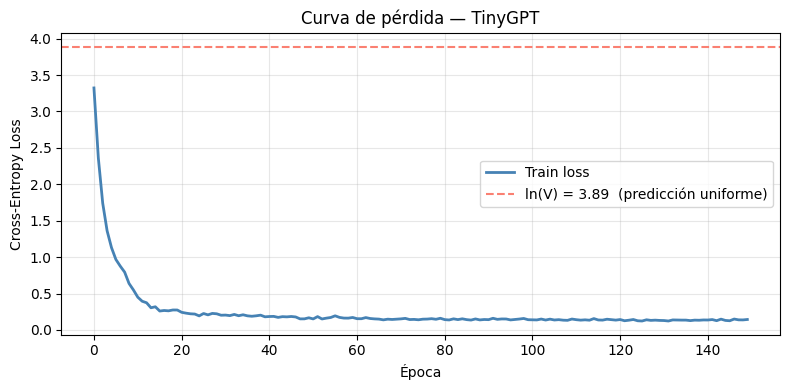

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(loss_history, color='steelblue', linewidth=2, label='Train loss')
ax.axhline(math.log(vocab_size), color='salmon', linestyle='--',
           label=f'ln(V) = {math.log(vocab_size):.2f}  (predicción uniforme)')
ax.set_xlabel("Época"); ax.set_ylabel("Cross-Entropy Loss")
ax.set_title("Curva de pérdida — TinyGPT")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Sección 10 — Generación autoregresiva

Una vez entrenado el modelo, generamos texto de forma autoregresiva:
el modelo predice un token, lo añade al contexto, y repite.
La **temperatura** controla la dispersión de la distribución:
valores bajos → más determinista, valores altos → más aleatorio.

In [17]:
def generate_text(prompt: str, max_new: int = 12, temperature: float = 0.8) -> str:
    model.eval()
    idx = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
    out = model.generate(idx, max_new_tokens=max_new, temperature=temperature)
    return decode(out[0].tolist())

print("=== Generación con temperatura 0.8 ===")
for p in ["el gato", "la niña", "el sol", "la luna"]:
    print(f"  '{p}' →  {generate_text(p)}")

print("\n=== Efecto de la temperatura ===")
for temp in [0.2, 0.8, 1.5]:
    print(f"  temp={temp}  →  {generate_text('el gato', temperature=temp)}")

=== Generación con temperatura 0.8 ===


  'el gato' →  el gato duerme en el sofá el perro corre por el parque la niña
  'la niña' →  la niña lee un libro en el jardín el sol brilla sobre el río
  'el sol' →  el sol ilumina el jardín y el río la luna y las estrellas brillan
  'la luna' →  la luna y las estrellas brillan en el cielo el viento mueve las hojas

=== Efecto de la temperatura ===
  temp=0.2  →  el gato duerme en el sofá el perro corre por el parque la niña
  temp=0.8  →  el gato duerme en el sofá el perro corre por el parque la niña
  temp=1.5  →  el gato duerme en el sofá el perro corre por el parque la niña


## Sección 11 — Visualización de attention maps

Los pesos de atención revelan a qué posiciones "mira" cada token.
El triángulo superior debe ser siempre exactamente 0 (máscara causal activa).
Cada cabeza puede especializarse en capturar patrones distintos.

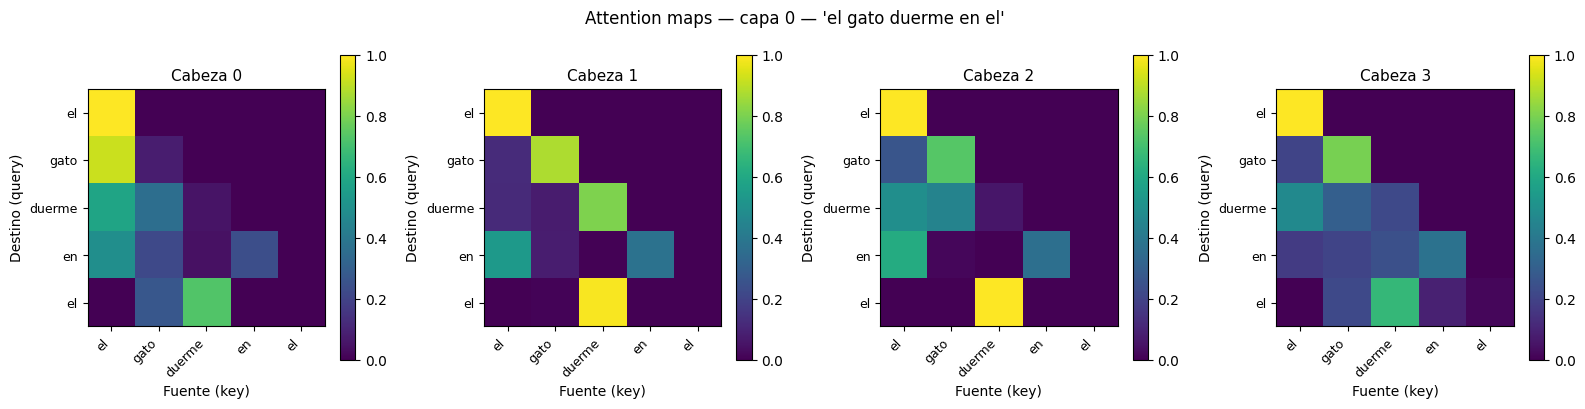

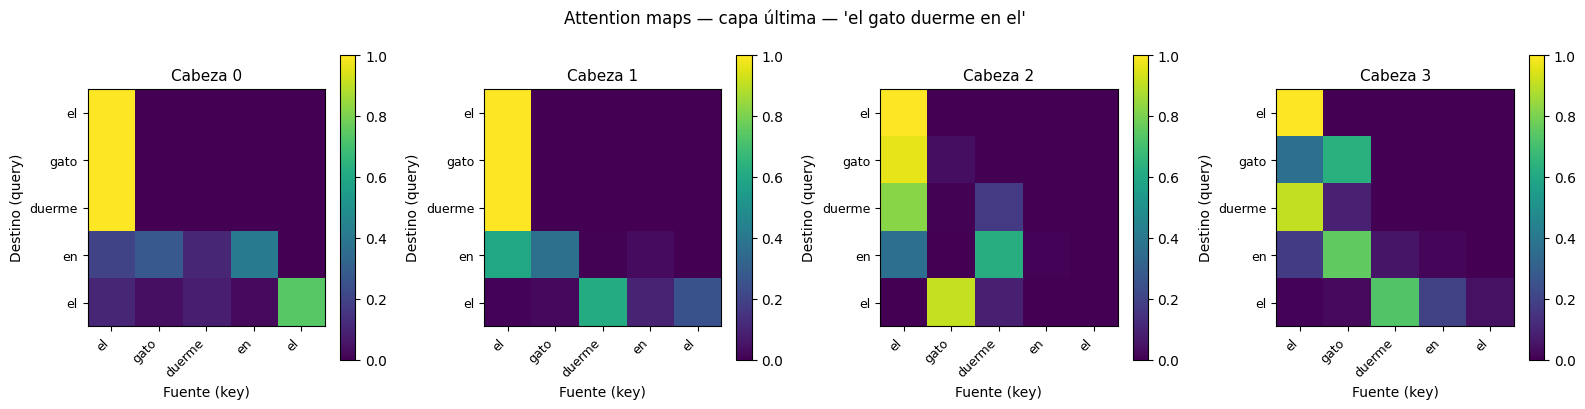

In [18]:
def plot_attention_maps(prompt: str, layer: int = -1):
    model.eval()
    tokens = encode(prompt)
    T_p    = len(tokens)
    idx    = torch.tensor([tokens], dtype=torch.long, device=device)

    with torch.no_grad():
        _, attn_maps = model(idx)

    attn   = attn_maps[layer][0].cpu().numpy()   # (n_heads, T, T)
    labels = [tokenizer.id_to_token(t) for t in tokens]

    fig, axes = plt.subplots(1, N_HEADS, figsize=(4 * N_HEADS, 4))
    for h, ax in enumerate(axes):
        im = ax.imshow(attn[h], cmap='viridis', vmin=0, vmax=1)
        ax.set_title(f"Cabeza {h}", fontsize=11)
        ax.set_xticks(range(T_p)); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
        ax.set_yticks(range(T_p)); ax.set_yticklabels(labels, fontsize=9)
        ax.set_xlabel("Fuente (key)"); ax.set_ylabel("Destino (query)")
        plt.colorbar(im, ax=ax)

    layer_name = "última" if layer == -1 else f"{layer}"
    fig.suptitle(f"Attention maps — capa {layer_name} — '{prompt}'", fontsize=12)
    plt.tight_layout(); plt.show()

plot_attention_maps("el gato duerme en el", layer=0)
plot_attention_maps("el gato duerme en el", layer=-1)

## Sección 12 — Los tres pasos del mecanismo de atención

Para hacer visible el efecto de la máscara, interceptamos los tensores internos
con un **forward hook** de PyTorch y visualizamos:

1. **Scores brutos** → `Q·Kᵀ / √d_k`
2. **+ Máscara** → `-∞` en el triángulo superior
3. **Softmax** → triángulo superior = exactamente 0

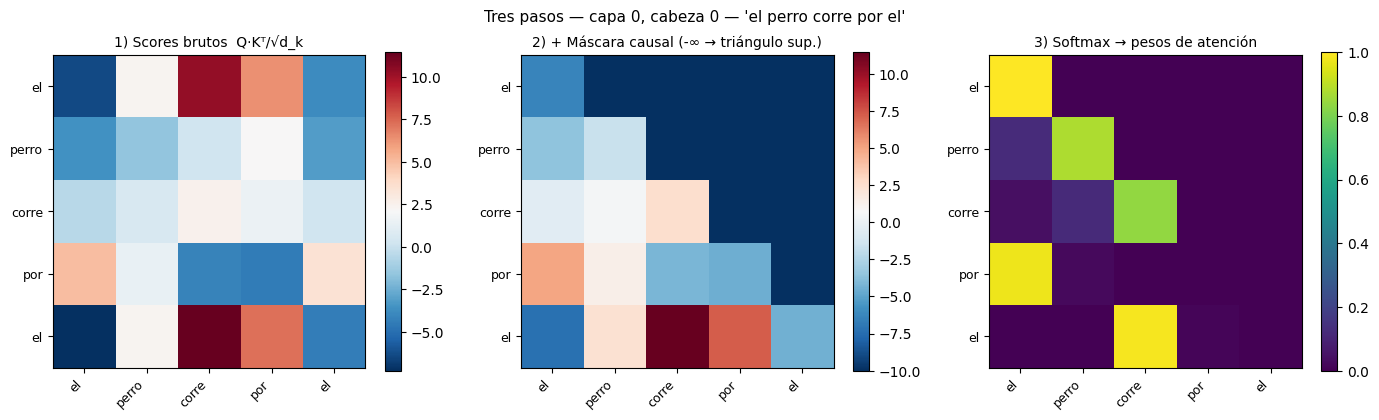

In [19]:
def visualize_masking_steps(prompt: str):
    model.eval()
    tokens = encode(prompt)
    T_p    = len(tokens)
    idx    = torch.tensor([tokens], dtype=torch.long, device=device)
    labels = [tokenizer.id_to_token(t) for t in tokens]

    captured = {}

    def hook_fn(module, input, output):
        with torch.no_grad():
            x       = input[0]; B, T, C = x.shape
            q, k, _ = module.qkv_proj(x).split(module.d_model, dim=-1)
            def rh(t): return t.view(B, T, module.n_heads, module.d_k).transpose(1, 2)
            q, k    = rh(q), rh(k)
            raw     = (q @ k.transpose(-2, -1)) / math.sqrt(module.d_k)
            masked  = raw + module.causal_mask[:, :, :T, :T]
            weights = F.softmax(masked, dim=-1)
            # Guardamos la cabeza 0
            captured['raw']     = raw[0, 0].cpu().numpy()
            captured['masked']  = masked[0, 0].cpu().numpy()
            captured['weights'] = weights[0, 0].cpu().numpy()

    hook = model.blocks[0].attn.register_forward_hook(hook_fn)
    with torch.no_grad(): model(idx)
    hook.remove()

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    titles    = ["1) Scores brutos  Q·Kᵀ/√d_k",
                 "2) + Máscara causal (-∞ → triángulo sup.)",
                 "3) Softmax → pesos de atención"]
    vis_masked = captured['masked'].clip(-10, None)
    data_list  = [captured['raw'], vis_masked, captured['weights']]
    cmaps      = ['RdBu_r', 'RdBu_r', 'viridis']

    for ax, data, title, cmap in zip(axes, data_list, titles, cmaps):
        im = ax.imshow(data, cmap=cmap)
        ax.set_title(title, fontsize=10)
        ax.set_xticks(range(T_p)); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
        ax.set_yticks(range(T_p)); ax.set_yticklabels(labels, fontsize=9)
        plt.colorbar(im, ax=ax)

    plt.suptitle(f"Tres pasos — capa 0, cabeza 0 — '{prompt}'", fontsize=11)
    plt.tight_layout(); plt.show()

visualize_masking_steps("el perro corre por el")

In [20]:
print("\n✓ Notebook completado.")


✓ Notebook completado.
